# Liam Gines, Tyrese Gill

# Churn Prediction
Shortcut to run all blocks: ESC, CTRL + A, SHIFT + ENTER

## Imports

In [309]:
# TODO: Save variables to file so that a user can run any section without having to run EVERYTHING
# Working with data
import numpy as np
import pandas as pd
# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing: encoding, scaling
from sklearn.preprocessing import LabelEncoder, StandardScaler, Normalizer

# For imbalanced datasets
from sklearn.utils import resample
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE, ADASYN

# Testing, model tuning
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

# Selected models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, f1_score

# For storing and loading machine learning models
import joblib

## Dataset Info

In [3]:
# Add data to a data frame
CSV_FILE = "Churn_Modelling.csv"
data_frame = pd.read_csv(CSV_FILE)

# Identifying attributes
TARGET = "Exited"
UNNECESSARY_FEATURES = ["RowNumber", "CustomerId", "Surname"]
NOMINAL_FEATURES = ["Surname", "Geography", "Gender"]

# Defining nominal features that will be kept: Geography, Gender
SELECTED_NOMINAL_FEATURES = list(set(NOMINAL_FEATURES) - set(UNNECESSARY_FEATURES))

RANDOM_STATE = 123
NUM_ROWS_TO_DISPLAY = 3

data_frame

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


## Dataset Stats

In [4]:
data_frame.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## No Values are Missing

In [5]:
data_frame.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## Display Class Imbalance of Target

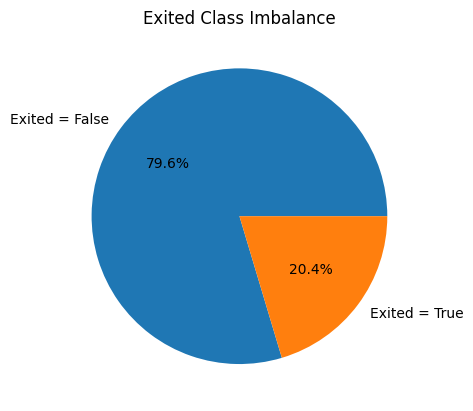

In [6]:
# https://wellsr.com/python/upsampling-and-downsampling-imbalanced-data-in-python/
def frame_target_imbalance(df):
    df.groupby(TARGET).size().plot(kind="pie", y=TARGET, title=f"{TARGET} Class Imbalance", labels=[f"{TARGET} = False", f"{TARGET} = True"], autopct="%1.1f%%")

frame_target_imbalance(data_frame)

## TEMPORARILY Label Encode Selected Nominal Features
This is temporarily done so these features will be shown on the box plot. Using the dataset with Nominal Features being Label Encoded is bad practice because a model might think there is some order to the Nominal Features when there isn't one in reality. We will transform the data frame to use One-hot encoding before training and testing later on. For more information, see https://stackoverflow.com/questions/36631163/what-are-the-pros-and-cons-between-get-dummies-pandas-and-onehotencoder-sciki. Finally, note that One-hot encoding led to an improvement in the Decision Tree's performance later on.

In [7]:
label_encoder = LabelEncoder()
for nominal_feature in SELECTED_NOMINAL_FEATURES:
    current_feature_values = data_frame[nominal_feature]
    label_encoder.fit(current_feature_values)
    data_frame[nominal_feature] = label_encoder.transform(current_feature_values)

data_frame.head(NUM_ROWS_TO_DISPLAY)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,0,0,42,8,159660.80,3,1,0,113931.57,1


## Show Feature Distributions

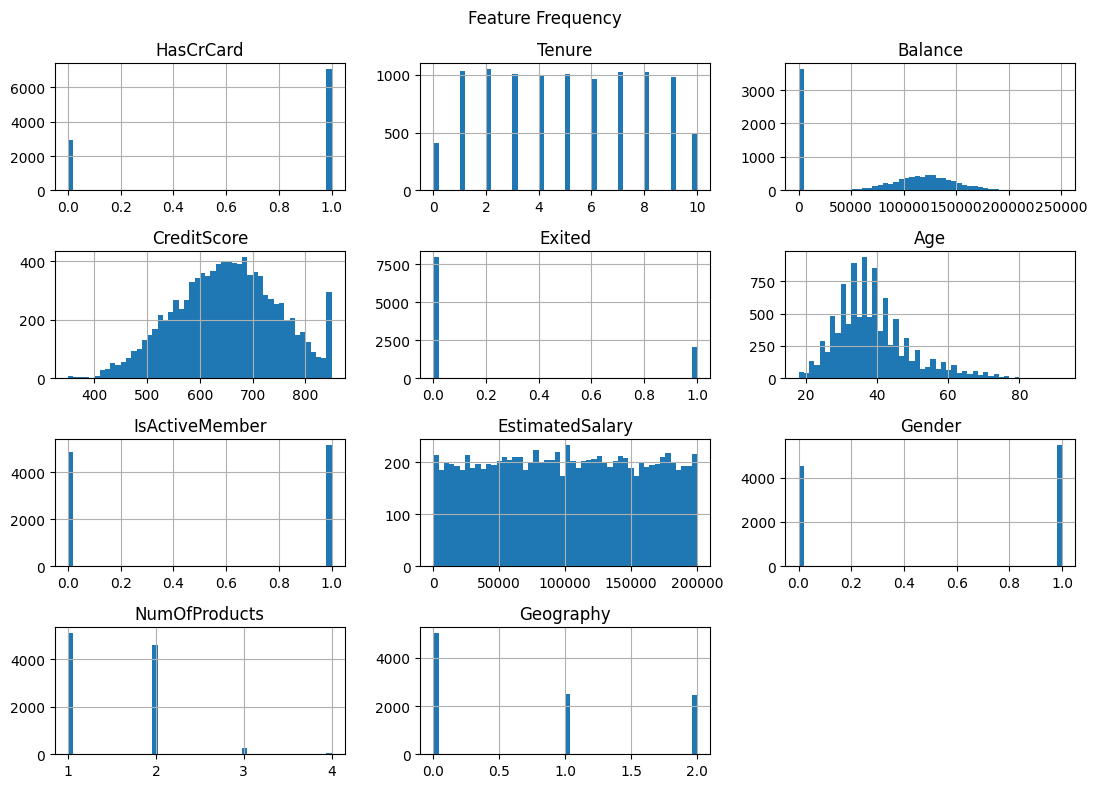

In [8]:
FEATURED_DISTRIBUTIONS = list(set(data_frame.columns) - set(UNNECESSARY_FEATURES))
data_frame[FEATURED_DISTRIBUTIONS].hist(figsize=(11, 8), bins=50)
plt.suptitle("Feature Frequency")
plt.tight_layout()
plt.show()

## Remove Unnecessary Features from the Dataset

In [9]:
data_frame = data_frame.drop(columns=UNNECESSARY_FEATURES)
data_frame.head(NUM_ROWS_TO_DISPLAY)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1


## Show Unscaled Features (Plot includes Target "Exited")

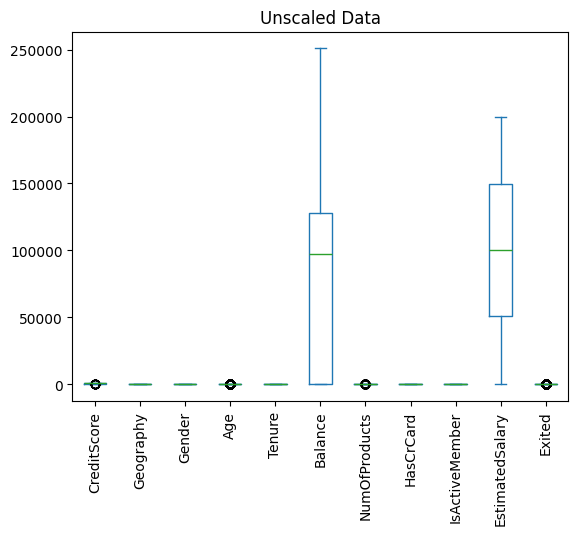

In [10]:
def frame_box_plot(df, title):
    df.plot(kind="box")
    plt.title(title)
    plt.xticks(rotation=90)
    plt.show()

frame_box_plot(data_frame, "Unscaled Data")

## Show Scaled Features (Plot includes Target "Exited")

**NOTE**: Do not use "data_frame_scaled" to produce training and test sets. This is because we do not want to scale the Target "Exited". We want to keep the Target as 0s and 1s. Scaling the Target will lead to problems later on, as it will instead label the values 0 and 1 as -1 and 1 instead. The box plot below is purely for showing the scaled features only.

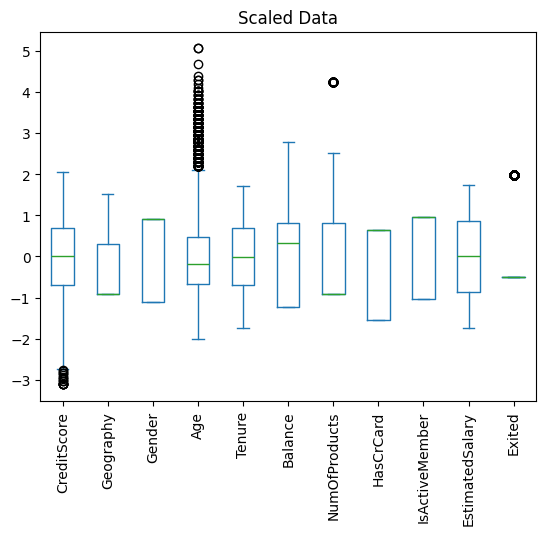

In [11]:
def get_scaled_frame(df):
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df)
    return pd.DataFrame(data=df_scaled, columns=df.columns)

data_frame_scaled = get_scaled_frame(data_frame)
frame_box_plot(data_frame_scaled, "Scaled Data")

## Choosing Outliers for Removal in Training
The outliers in "NumOfProducts" seemed like it might cause issues for our models and it actually did in practice.
Age seems to capture something important, so we have left its outliers in. You can see the directly proportional relationship between churning customers and age in the Correlation Matrix.

Below are some other combinations of outliers that we tried excluding from our training sets.

In [12]:
# OUTLIERS_TO_REMOVE_IN_TRAINING = ["NumOfProducts", "Age"]
# OUTLIERS_TO_REMOVE_IN_TRAINING = ["NumOfProducts", "CreditScore"]
# OUTLIERS_TO_REMOVE_IN_TRAINING = ["NumOfProducts", "CreditScore", "Age"]

OUTLIERS_TO_REMOVE_IN_TRAINING = ["NumOfProducts"]

## Show Normalized Features (Plot includes Target "Exited")
**NOTE**: Do not use "data_frame_normalized" to produce training and test sets because we do not want to normalize the Target either. This is only done to illustrate the effect of normalization.

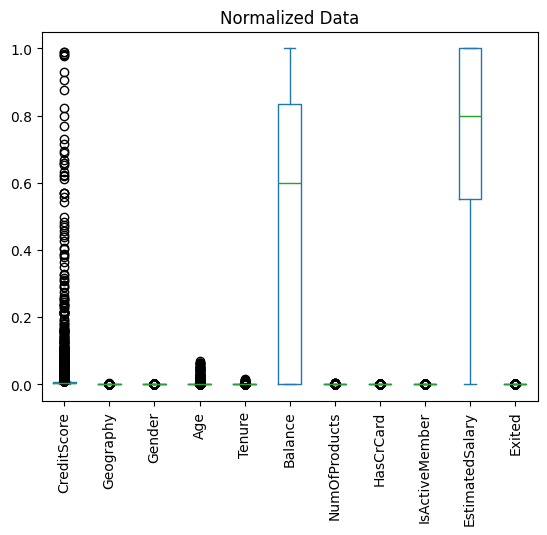

In [13]:
def get_normalized_frame(df):
    normalizer = Normalizer()
    df_normalized = normalizer.fit_transform(df)
    return pd.DataFrame(data=df_normalized, columns=df.columns)

data_frame_normalized = get_normalized_frame(data_frame)
frame_box_plot(data_frame_normalized, "Normalized Data")

## Applying One-Hot Encoding to Selected Nominal Features

In [14]:
data_frame = pd.get_dummies(data_frame, columns=SELECTED_NOMINAL_FEATURES, drop_first=False)
data_frame.head(NUM_ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_0,Geography_1,Geography_2,Gender_0,Gender_1
0,619,42,2,0.00,1,1,1,101348.88,1,True,False,False,True,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,False,True,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,True,False,False,True,False


## Show Correlation Among Features After One-Hot Encoding

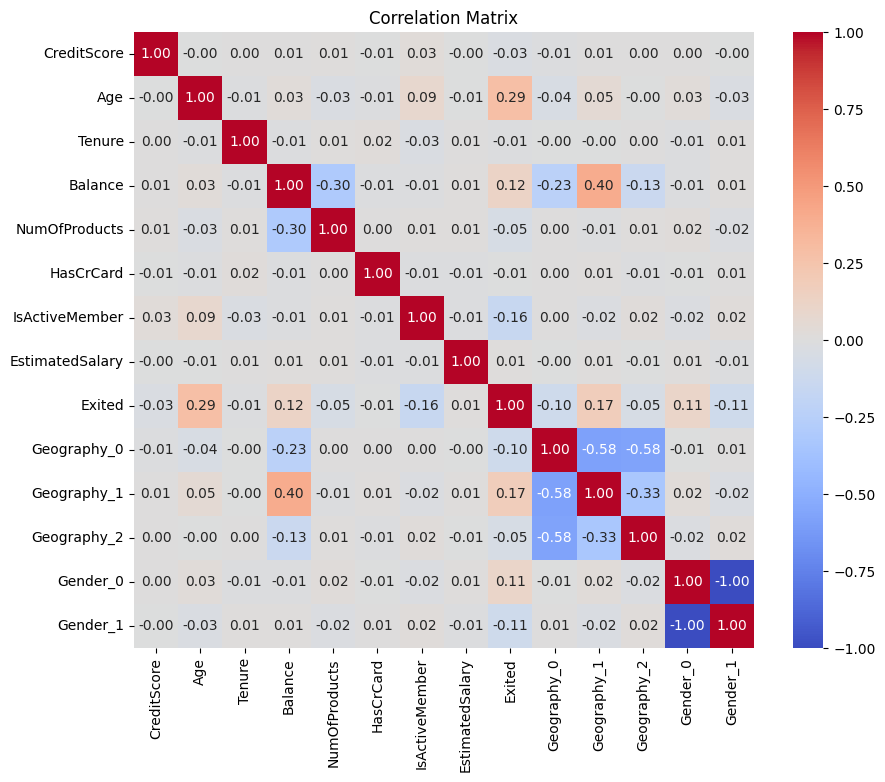

In [15]:
# Threshold parameter is used to easily identify certain features that are correlated beyond a specified threshold
def frame_correlation_matrix(df, threshold=0):
    correlation_matrix = df.corr()
    correlation_matrix[abs(correlation_matrix) < threshold] = 0
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Matrix")
    plt.show()

frame_correlation_matrix(data_frame)

## Highlight Features that are Correlated Beyond a Specified Threshold

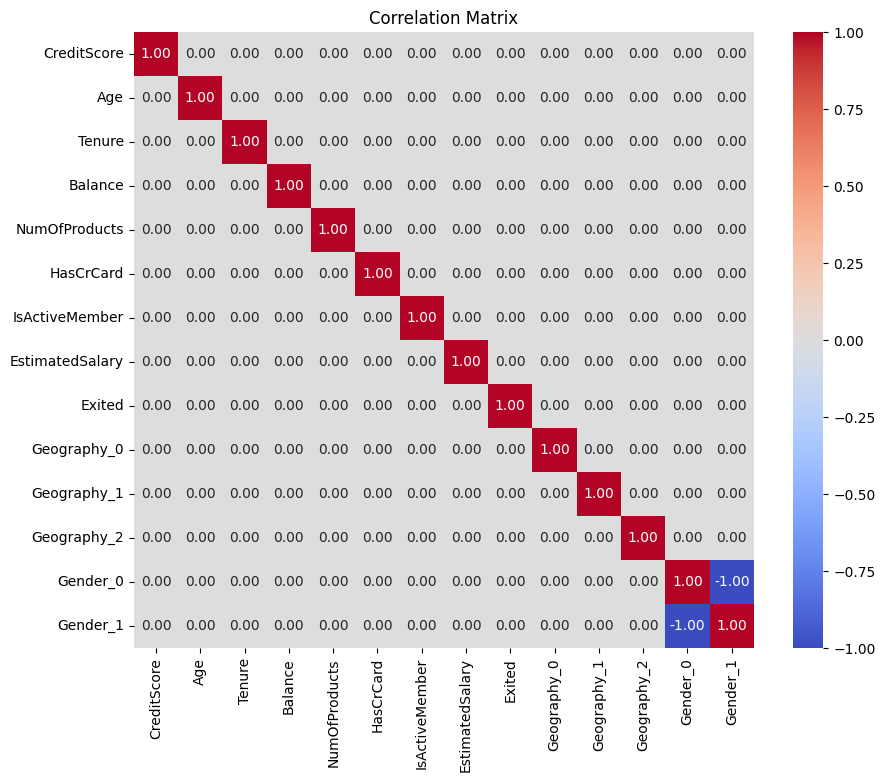

In [16]:
CORRELATION_THRESHOLD_FOR_FEATURE_REMOVAL = 0.8
frame_correlation_matrix(data_frame, CORRELATION_THRESHOLD_FOR_FEATURE_REMOVAL)

## Drop One Gender Column to Reduce Dimensionality and Information Redundancy
We do this because it is highly correlated with the other Gender column.

In [17]:
data_frame = data_frame.drop(columns=["Gender_1"])
data_frame.head(NUM_ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_0,Geography_1,Geography_2,Gender_0
0,619,42,2,0.00,1,1,1,101348.88,1,True,False,False,True
1,608,41,1,83807.86,1,0,1,112542.58,0,False,False,True,True
2,502,42,8,159660.80,3,1,0,113931.57,1,True,False,False,True


## Define Unscaled Features (x) and Target (y)

In [18]:
# Define function for getting unscaled, scaled and normalized x
# This function also retrieves the unscaled Target column
def get_x_y(df, scale=False, normalize=False):
    x = df.drop(columns=[TARGET])
    if scale:
        x = get_scaled_frame(x)
    elif normalize:
        x = get_normalized_frame(x)
    y = df[TARGET]
    return x, y

x, y = get_x_y(data_frame)

x.head(NUM_ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_0,Geography_1,Geography_2,Gender_0
0,619,42,2,0.00,1,1,1,101348.88,True,False,False,True
1,608,41,1,83807.86,1,0,1,112542.58,False,False,True,True
2,502,42,8,159660.80,3,1,0,113931.57,True,False,False,True


## Define Scaled Features (x_std)

In [19]:
x_std, _ = get_x_y(data_frame, scale=True)
x_std.head(NUM_ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_0,Geography_1,Geography_2,Gender_0
0,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886,0.997204,-0.578736,-0.573809,1.095988
1,-0.440036,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,-1.002804,-0.578736,1.742740,1.095988
2,-1.536794,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,0.997204,-0.578736,-0.573809,1.095988


## Define Normalized Features (x_normalized)

In [20]:
x_normalized, _ = get_x_y(data_frame, scale=False, normalize=True)
x_normalized.head(NUM_ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_0,Geography_1,Geography_2,Gender_0
0,0.006108,0.000414,0.000020,0.000000,0.000010,0.000010,0.000010,0.999981,0.000010,0.0,0.000000,0.000010
1,0.004333,0.000292,0.000007,0.597258,0.000007,0.000000,0.000007,0.802037,0.000000,0.0,0.000007,0.000007
2,0.002559,0.000214,0.000041,0.814000,0.000015,0.000005,0.000000,0.580859,0.000005,0.0,0.000000,0.000005


## Define Helper Functions for Conveniently Testing Models

In [21]:
def call_train_test_split(x, y, train_size=0.8):
    return train_test_split(x, y, train_size=train_size, test_size=(1 - train_size), random_state=RANDOM_STATE, stratify=y)

def custom_train_test_split(x, y, outliers_to_remove=[], upsample_minority=False, add_synthetic_training_data=False, train_size=0.8):
    """
    Returns training and test sets for x and y respectively (x_train, x_test, y_train, y_test)
    x_train and y_train exclude any of the outliers specified in outliers_to_remove
    x_train and y_train upsample the minority class if upsample_minority == True
    x_train and y_train use a method to generate synthetic data points if add_synthetic_training_data == True
    train_size controls the size of the training data and test data respectively where test_size == 1 - train_size

    x_test and y_test are sampled in their raw form without any processing so that when we test our models, 
    it simulates how the model would actually perform in a real world scenario.
    """
    x_train, x_test, y_train, y_test = call_train_test_split(x, y, train_size)
    
    # https://stackoverflow.com/questions/74683825/how-do-i-remove-outliers-from-a-column-in-a-dataframe
    # Reconstruct data frame using x and y. Essentially, concatenate x with y to produce the original dataframe.
    # This is done because we need to keep x and y consistent with each other.
    df_train = x.copy()
    df_train[TARGET] = y
    if outliers_to_remove:
        # When we remove an outlier from x, we also need to remove the corresponding row in y.
        for outlier in outliers_to_remove:
            quartile1 = df_train[outlier].quantile(0.25)
            quartile3 = df_train[outlier].quantile(0.75)
            interquartile_range = quartile3 - quartile1

            low = quartile1 - 1.5 * interquartile_range
            high = quartile3 + 1.5 * interquartile_range

            df_train = df_train[df_train[outlier] > low]
            df_train = df_train[df_train[outlier] < high]

        x_removed_outliers, y_removed_outliers = get_x_y(df_train)
        # Update x_train and y_train to only include rows without any outliers
        x_train, _, y_train, _ = call_train_test_split(x_removed_outliers, y_removed_outliers)

    if upsample_minority:
        df_train_minority = df_train[df_train[TARGET] == 1]
        df_train_majority = df_train[df_train[TARGET] == 0]

        df_train_minority_upsample = resample(df_train_minority, replace=True, n_samples=len(df_train_majority), random_state=RANDOM_STATE)
        df_train_upsample = pd.concat([df_train_majority, df_train_minority_upsample])

        x_minority_upsample, y_minority_upsample = get_x_y(df_train_upsample)
        # Update x_train and y_train to have upsampled the minority class
        x_train, _, y_train, _ = call_train_test_split(x_minority_upsample, y_minority_upsample)

    if add_synthetic_training_data:
        # Update x_train and y_train to include synthetic data based on one of the recommended techniques below
        adasyn = ADASYN(random_state=RANDOM_STATE)
        smote = SMOTE(random_state=RANDOM_STATE)
        smote_enn = SMOTEENN(random_state=RANDOM_STATE)
        
        if add_synthetic_training_data.upper() == "ADASYN":
            x_train, y_train = adasyn.fit_resample(x_train, y_train)
            
        elif add_synthetic_training_data.upper() == "SMOTE":
            x_train, y_train = smote.fit_resample(x_train, y_train)

        # Default case applies SMOTEENN
        else:
            x_train, y_train = smote_enn.fit_resample(x_train, y_train)
    
    return x_train, x_test, y_train, y_test

def test_model(model, x, y, outliers_to_remove=[], upsample_minority=False, add_synthetic_training_data=False, output=True):
    """
    Returns the fitted model, training and test f1 scores respectively (model, training_f1_score, test_f1_score).
    
    Splits data into training and test sets based on the specified parameters. See the custom_train_test_split() function for more information.
    Model is then fitted on the training data.
    The model then tries to predict the training and test sets.

    If output == True, information about the model and how the Training Data was transformed is shown to the user.
    The Training and Test Classification Report is then printed. A Confusion Matrix visual is shown.
    If the model has a function called "predict_proba", it will plot a ROC Curve.
    If the model is a Decision Tree, it will show a visual of the tree model.
    """
    x_train, x_test, y_train, y_test = custom_train_test_split(x, y, outliers_to_remove, upsample_minority, add_synthetic_training_data)
    model.fit(x_train, y_train)
    y_train_predicted = model.predict(x_train)
    y_test_predicted = model.predict(x_test)

    if output:
        print(model)
        print(f"{outliers_to_remove=}, {upsample_minority=}, {add_synthetic_training_data=}")
        report = classification_report(y_test, y_test_predicted, output_dict=True)
        precision_churned = round(report['1']['precision'], 3)
        recall_churned = round(report['1']['recall'], 3)
        f1_churned = round(report['1']['f1-score'], 3)
        accuracy = round(report['accuracy'], 3)
    
        '''confusion_matrix_test = confusion_matrix(y_test, y_test_predicted)
        confusion_matrix_display = ConfusionMatrixDisplay(confusion_matrix_test, display_labels=model.classes_)
        figure, axes = plt.subplots(figsize=(2, 2))
        confusion_matrix_display.plot(ax=axes)
        plt.show()'''
    
        predict_proba = getattr(model, "predict_proba", None)
        if callable(predict_proba):
            y_test_predicted_class_probabilities = model.predict_proba(x_test)
            y_test_predicted_minority_probabilites = y_test_predicted_class_probabilities[:, 1]
            fpr, tpr, thresholds = roc_curve(y_test, y_test_predicted_minority_probabilites)
            area_under_curve = auc(fpr, tpr)
        
        '''if type(model) == type(DecisionTreeClassifier()):
            plot_tree(model, filled=True)'''
        
        return (precision_churned, recall_churned, f1_churned, accuracy), (fpr, tpr, area_under_curve)

    training_f1_score = f1_score(y_train, y_train_predicted)
    test_f1_score = f1_score(y_test, y_test_predicted)
    return model, training_f1_score, test_f1_score

## Define Helper Function for Hyperparameter Tuning

In [22]:
def tune_hyperparameters(model, x, y, parameter_grid, search_strategy, outliers_to_remove=[], upsample_minority=False, add_synthetic_training_data=False):
    scoring = "f1"
    error_score = "raise"    
    assert search_strategy in ["random", "grid"], f"Invalid Search Strategy: {search_strategy}"

    x_train, _, y_train, _ = custom_train_test_split(x, y, outliers_to_remove, upsample_minority, add_synthetic_training_data)

    if search_strategy == "random":
        searchcv = RandomizedSearchCV(model, param_distributions=parameter_grid, random_state=RANDOM_STATE, scoring=scoring, error_score=error_score, n_jobs=-1)
    else:
        searchcv = GridSearchCV(model, param_grid=parameter_grid, scoring=scoring, error_score=error_score, n_jobs=-1)
    searchcv.fit(x_train, y_train)

    tuned_model = searchcv.best_estimator_
    print(f"{tuned_model=}")
    return tuned_model

## Define Helper Function To Generate "class_weight" Parameters for Various Models

In [23]:
def generate_binary_class_weights(rate_of_change=0.05, majority_class=0, minority_class=1, ceiling=1, floor = 0):
    class_weights = []
    assert 0 < rate_of_change, 'Input a rate of change between 0 and 1!'

    minority_value = ceiling - rate_of_change
    majority_value = 1 - minority_value
    while minority_value > floor and majority_value < ceiling:
        class_weight = {}
        class_weight[minority_class] = round(minority_value, 3)
        class_weight[majority_class] = round(1 - minority_value, 3)
        minority_value -= rate_of_change
        class_weights.append(class_weight)
    return class_weights

def tune_class_weights(weighted_model, x, y, parameter_grid, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=False, add_synthetic_training_data=False, search_strategy='grid'):
    optimal_cls_weight = weighted_model.class_weight[1]
    rate_of_changes = [0.01, 0.001]
    intervals = [0.05, 0.005]
    for roc, interval in zip(rate_of_changes, intervals):
        parameter_grid = {"class_weight": generate_binary_class_weights(rate_of_change=roc, ceiling=optimal_cls_weight+interval, floor=optimal_cls_weight-interval)}
        weighted_model = tune_hyperparameters(weighted_model, x, y, parameter_grid, search_strategy, outliers_to_remove, upsample_minority, add_synthetic_training_data)
        optimal_cls_weight = weighted_model.class_weight[1]
    return weighted_model

CLASS_WEIGHTS = generate_binary_class_weights()

## Define Helper Function for Visually Comparing Multiple Models

In [24]:
def visualize_auc(model_aucs: dict, title: str):
    assert type(model_aucs) == dict, f'Dictionary object expected. Type {type(model_aucs)} inputted.'
    assert type(title) == str, f'String object expected. Type {type(title)} inputted.'

    plt.figure(figsize=(6, 4))

    # Plots ROC curve for each model
    for name, auc_metrics in model_aucs.items():
        fpr, tpr, auc = auc_metrics
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')

    plt.plot([0, 1], [0, 1], linestyle="--", color='gray')

    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def visualize_metrics(model_metrics: dict, technique: str, metrics = ['F1-Score']):
    assert type(model_metrics), f'Dictionary object expected. Type {type(model_metrics)} inputted.'
    assert type(technique), f'String object expected. Type {type(technique)} inputted.'
    for index, metric_name in enumerate(metrics):
        current_metric_values = {
            model: metric_tuple[index]
            for model, metric_tuple in model_metrics.items()
        }
        df = pd.DataFrame(current_metric_values.items(), columns=['Model', metric_name])

        # Plot
        plt.figure(figsize=(8, 5))
        sns.barplot(data=df, x=metric_name, y='Model')  # Swapped x and y
        plt.xlim(0, 1.1)  # x-axis now holds metric values
        plt.title(f'{metric_name} Comparison ({technique})')
        plt.xlabel(metric_name)
        plt.ylabel('Model')
        plt.axvline(x=0.5, color='red', linestyle='--', linewidth=1)
        plt.grid(True, linestyle='--', alpha=0.6, axis='x')  # Grid lines on x-axis now
        plt.tight_layout()
        plt.show()


## Define Helper Function for Displaying and Saving Metric Scores

In [148]:
def display_and_store_metrics(model_names: list, model_metrics_list: list, table_name: str, caption: str = None):
    assert type(model_names) == list, f'List object expected. Type {type(model_names)} inputted.'
    assert type(model_metrics_list) == list, f'List object expected. Type {type(model_metrics_list)} inputted.'
    assert type(table_name) == str, f'String object expected. Type {type(table_name)} inputted.'
    assert len(model_names) == len(model_metrics_list), f'The length of model_names and model_metrics_list need to be the same. \
    Lengths are {len(model_names)} and {len(model_metrics_list)}.'

    metrics = {'Precision': {},
               'Recall': {},
               'F1-Score': {},
               'Accuracy': {}
               }
    
    # Organizes the corresponding metrics for each model
    for name, (precision, recall, f1, accuracy) in zip(model_names, model_metrics_list):
        metrics['Precision'][name] = precision
        metrics['Recall'][name] = recall
        metrics['F1-Score'][name] = f1
        metrics['Accuracy'][name] = accuracy
    
    # Calculates average for each metric
    for _, model_dict in metrics.items():
        average = np.mean(list(model_dict.values()))
        model_dict['Average'] = round(average, 3)
    
    # Organizes the model-metric pairings to form a dataframe
    df = pd.concat(
        [ pd.DataFrame.from_dict(metrics[metric], orient='index', columns=[metric])
         for metric in ['F1-Score', 'Recall', 'Precision', 'Accuracy'] ],
    axis=1)

    df.to_csv(f'{table_name}.csv')

    return df

## Define Helper Functions for Determining Most Favored Technique

In [136]:
def split_models_by_favored_technique(dfs: list[pd.DataFrame], technique_names: list[str], primary_metric: str, secondary_metric: str):
    metrics = ['F1-Score', 'Recall', 'Precision', 'Accuracy']
    assert len(dfs) == len(technique_names), 'Each DataFrame must have a corresponding technique name.'
    assert primary_metric in metrics, f'The primary metric "{primary_metric}" not in list of metrics: {metrics}.'
    assert secondary_metric in metrics, f'The secondary metric "{secondary_metric}" not in list of metrics: {metrics}.'
    assert primary_metric != secondary_metric, f'You cannot use the same metric as your primary and secondary' 
    
    # Initialize result dictionary
    favored_models_by_technique = {name: [] for name in technique_names}

    # Get list of models (exclude Average)
    models = [model for model in dfs[0].index if model != "Average"]

    for model in models:
        # Get primary metric scores across all techniques for this model
        primary_scores = [df.loc[model, primary_metric] for df in dfs]
        max_primary = max(primary_scores)

        # Get indices of techniques with the highest primary metric
        best_indices = [index for index, score in enumerate(primary_scores) if score == max_primary]

        if len(best_indices) == 1:
            # Only one best technique
            favored_models_by_technique[technique_names[best_indices[0]]].append(model)
        else:
            # Tie on primary metric, secondary metric acts as tie breaker
            secondary_scores = [dfs[i].loc[model, secondary_metric] for i in best_indices]
            max_secondary = max(secondary_scores)
            best_secondary_index = best_indices[secondary_scores.index(max_secondary)]
            favored_models_by_technique[technique_names[best_secondary_index]].append(model)

    return favored_models_by_technique

def check_most_favorable(model, techniques: list, technique, technique_name: str = None, technique_data_return: dict = None):
    """Determines whether a given technique is the most optimal and should be turned on and applied to a model."""
    model_name = type(model).__name__
    models_class_name = {
        'DecisionTreeClassifier': 'Decision Tree',
        'RandomForestClassifier': 'Random Forest',
        'LogisticRegression': 'Logistic Regression',
        'SVC': 'SVM',
        'MLPClassifier': 'MLP',
        'GaussianNB': 'Naive Bayes'
    }
    
    assert model_name in ['DecisionTreeClassifier', 'SVC', 'MLPClassifier', 'LogisticRegression', 'GaussianNB', 'RandomForestClassifier'], f'The model "{model_name}" is not valid. Valid models: {models_class_name.keys()}.'
    if technique is not None:
        if isinstance(technique, str):
            technique_name = technique.lower()
        elif isinstance(technique, dict):
            technique_data_return = technique
        else:
            raise TypeError("A string or dictionary object was expected.")
    else:
        raise TypeError("A string or dictionary object was expected.")
        
    if (technique_name is not None) and (technique_data_return is not None):
        raise ValueError("Provide only technique_name or technique_data_return, not both.")
    """if technique_name:
        assert technique_name in techniques, f'The technique "{technique_name}" is not a valid technique. Valid techniques: {techniques}.'"""
    if technique_data_return:
        assert type(technique_data_return) is dict, f'{technique_data_return} should be Dictionary object.'
        assert set(technique_data_return.keys()) == set(techniques), f'{technique_data_return.keys()} does not match {techniques}.'

    model_name = models_class_name[model_name]
    for technique in techniques:
        if model_name in favored_models[technique]:
            tech_fav_pair = favored_models[technique], technique
    if technique_data_return:
        return tech_fav_pair
        '''for technique in techniques:
            if model_name in favored_models[technique]:
                return technique_data[technique], technique'''
    else:
        if model_name in favored_models[technique_name]:
            _, fav_technique = tech_fav_pair
            return True, fav_technique
        else:
            _, fav_technique = tech_fav_pair
            return False, fav_technique

## Define Helper Functions for Calculating Feature Importances

In [27]:
class FeatureImportance:
    def __init__(self, name, importance):
        self.name = name
        self.importance = importance

    def __lt__(self, other):
        return self.importance > other.importance

    def __str__(self):
        return f"{self.name}: {self.importance * 100:.2f}%"

def feature_importance_bar(feature_names, feature_importance):
    """
    for i in range(len(feature_names)):
        feature_name = feature_names[i]
        feature_names[i] = feature_name.replace("_", "\n")
    """
        
    plt.barh(y=feature_names, width=feature_importance)
    plt.title("Random Forest Feature Importance Scores")
    plt.grid(True, axis='x')
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature Name")
    plt.tight_layout()
    plt.show()

# Testing Untuned Models Trained on Samples of Uncleaned Data

In [28]:
x_train_uncleaned, _, _, _ = custom_train_test_split(x, y, outliers_to_remove=[], upsample_minority=False, add_synthetic_training_data=False, train_size=0.8)
x_train_uncleaned.head(NUM_ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_0,Geography_1,Geography_2,Gender_0
9385,687,44,8,95368.14,2,1,1,1787.85,False,True,False,False
2155,660,35,6,100768.77,1,1,0,19199.61,True,False,False,True
768,684,41,2,119782.72,2,0,0,120284.67,False,False,True,False


## Decision Tree

In [29]:
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
raw_dt_metrics, raw_dt_auc = test_model(dt, x, y)

DecisionTreeClassifier(random_state=123)
outliers_to_remove=[], upsample_minority=False, add_synthetic_training_data=False


## Support Vector Machine

In [30]:
svm = SVC(random_state=RANDOM_STATE, probability=True)
raw_svm_metrics, raw_svm_auc = test_model(svm, x, y)

SVC(probability=True, random_state=123)
outliers_to_remove=[], upsample_minority=False, add_synthetic_training_data=False


C:\Users\gillt\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\gillt\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\gillt\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

## Multilayer Perceptron

In [31]:
mlp = MLPClassifier(random_state=RANDOM_STATE)
raw_mlp_metrics, raw_mlp_auc = test_model(mlp, x, y)

MLPClassifier(random_state=123)
outliers_to_remove=[], upsample_minority=False, add_synthetic_training_data=False


## Logistic Regression

In [32]:
lr = LogisticRegression(random_state=RANDOM_STATE)
raw_lr_metrics, raw_lr_auc = test_model(lr, x, y)

LogisticRegression(random_state=123)
outliers_to_remove=[], upsample_minority=False, add_synthetic_training_data=False


C:\Users\gillt\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Naive Bayes

In [33]:
nb = GaussianNB()
raw_nb_metrics, raw_nb_auc = test_model(nb, x, y)

GaussianNB()
outliers_to_remove=[], upsample_minority=False, add_synthetic_training_data=False


## Random Forest

In [34]:
rf = RandomForestClassifier(random_state=RANDOM_STATE)
raw_rf_metrics, raw_rf_auc = test_model(rf, x, y)

RandomForestClassifier(random_state=123)
outliers_to_remove=[], upsample_minority=False, add_synthetic_training_data=False


## Summary Table for Default Models

In [149]:
model_names = ['Decision Tree', 'SVM', 'MLP', 'Logistic Regression', 'Naive Bayes', 'Random Forest']
model_metrics_list = [raw_dt_metrics, raw_svm_metrics, raw_mlp_metrics, raw_lr_metrics, raw_nb_metrics, raw_rf_metrics]
raw_results = display_and_store_metrics(model_names, model_metrics_list, 'raw_results')
raw_results

,F1-Score,Recall,Precision,Accuracy
Decision Tree,0.495,0.499,0.490,0.792
SVM,0.000,0.000,0.000,0.796
MLP,0.271,0.310,0.241,0.661
Logistic Regression,0.126,0.074,0.423,0.791
Naive Bayes,0.136,0.086,0.327,0.778
Random Forest,0.620,0.506,0.798,0.874
Average,0.275,0.246,0.380,0.782


# Testing Untuned Models Trained on Samples of Cleaned Data
Cleaning the data here involved dropping the outliers we selected earlier (i.e. the outliers in the NumOfProducts column).

In [36]:
x_train_cleaned, _, _, _ = custom_train_test_split(x, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=False, add_synthetic_training_data=False, train_size=0.8)
x_train_cleaned.head(NUM_ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_0,Geography_1,Geography_2,Gender_0
3549,675,61,5,62055.17,3,1,0,166305.16,True,False,False,True
5961,796,32,5,102773.15,2,0,1,117832.88,False,False,True,False
7938,805,39,2,0.00,1,0,0,166650.32,True,False,False,False


## Decision Tree

In [37]:
clean_dt_metrics, clean_dt_auc = test_model(dt, x, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

DecisionTreeClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False


## Support Vector Machine

In [38]:
clean_svm_metrics, clean_svm_auc = test_model(svm, x, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

SVC(probability=True, random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False


C:\Users\gillt\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\gillt\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\gillt\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

## Multilayer Perceptron (MLP)

In [39]:
clean_mlp_metrics, clean_mlp_auc = test_model(mlp, x, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

MLPClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False


## Logistic Regression

In [40]:
clean_lr_metrics, clean_lr_auc = test_model(lr, x, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

LogisticRegression(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False


C:\Users\gillt\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Naive Bayes

In [41]:
clean_nb_metrics, clean_nb_auc = test_model(nb, x, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

GaussianNB()
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False


## Random Forest

In [42]:
clean_rf_metrics, clean_rf_auc = test_model(rf, x, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

RandomForestClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False


## Summary Table for Default Models Trained on Clean Data

In [43]:
model_names = ['Decision Tree', 'SVM', 'MLP', 'Logistic Regression', 'Naive Bayes', 'Random Forest']
model_metrics_list = [clean_dt_metrics, clean_svm_metrics, clean_mlp_metrics, clean_lr_metrics, clean_nb_metrics, clean_rf_metrics]
cleaned_results = display_and_store_metrics(model_names, model_metrics_list, 'cleaned_results')
cleaned_results

,F1-Score,Recall,Precision,Accuracy
Decision Tree,0.743,0.892,0.637,0.875
SVM,0.000,0.000,0.000,0.796
MLP,0.000,0.000,0.000,0.796
Logistic Regression,0.162,0.098,0.455,0.792
Naive Bayes,0.143,0.091,0.339,0.779
Random Forest,0.870,0.889,0.852,0.946
Average,0.320,0.328,0.380,0.831


# Testing Untuned Models Trained on Samples of Scaled & Cleaned Data

## Standardized & Cleaned Data

In [44]:
x_train_scaled_cleaned, _, _, _ = custom_train_test_split(x_std, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=False, add_synthetic_training_data=False, train_size=0.8)
x_train_scaled_cleaned.head(NUM_ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_0,Geography_1,Geography_2,Gender_0
3549,0.253198,2.105236,-0.004426,-0.231283,2.527057,0.646092,-1.030670,1.151411,0.997204,-0.578736,-0.573809,1.095988
5961,1.505158,-0.660018,-0.004426,0.421309,0.807737,-1.547768,0.970243,0.308527,-1.002804,-0.578736,1.742740,-0.912419
7938,1.598279,0.007457,-1.041760,-1.225848,-0.911583,-1.547768,-1.030670,1.157413,0.997204,-0.578736,-0.573809,-0.912419


## Normalized & Cleaned Data (x_train_normalized_cleaned)

In [45]:
x_train_normalized_cleaned, _, _, _ = custom_train_test_split(x_normalized, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=False, add_synthetic_training_data=False, train_size=0.8)
x_train_normalized_cleaned.head(NUM_ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_0,Geography_1,Geography_2,Gender_0
8636,0.005724,0.000438,0.000019,0.950306,0.000010,0.000010,0.000010,0.311263,0.000010,0.0,0.000000,0.000000
3789,0.002790,0.000206,0.000018,0.408292,0.000005,0.000005,0.000005,0.912847,0.000000,0.0,0.000005,0.000005
1973,0.004431,0.000262,0.000026,0.000000,0.000013,0.000000,0.000000,0.999990,0.000006,0.0,0.000000,0.000000


## Decision Tree

In [46]:
std_dt_metrics, std_dt_auc = test_model(dt, x_std, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

DecisionTreeClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False


In [47]:
norm_dt_metrics, norm_dt_auc = test_model(dt, x_normalized, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

DecisionTreeClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False


## Support Vector Machine

In [48]:
std_svm_metrics, std_svm_auc = test_model(svm, x_std, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

SVC(probability=True, random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False


In [49]:
norm_svm_metrics, norm_svm_auc = test_model(svm, x_normalized, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

SVC(probability=True, random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False


C:\Users\gillt\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\gillt\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\gillt\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

## Multilayer Perceptron (MLP)

In [50]:
std_mlp_metrics, std_mlp_auc = test_model(mlp, x_std, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

MLPClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False


C:\Users\gillt\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [51]:
norm_mlp_metrics, norm_mlp_auc = test_model(mlp, x_normalized, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

MLPClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False


C:\Users\gillt\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\gillt\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\gillt\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

## Logistic Regression

In [52]:
std_lr_metrics, std_lr_auc = test_model(lr, x_std, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

LogisticRegression(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False


In [53]:
norm_lr_metrics, norm_lr_auc = test_model(lr, x_normalized, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

LogisticRegression(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False


C:\Users\gillt\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\gillt\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\gillt\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

## Naive Bayes

In [54]:
std_nb_metrics, std_nb_auc = test_model(nb, x_std, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

GaussianNB()
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False


In [55]:
norm_nb_metrics, norm_nb_auc = test_model(nb, x_normalized, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

GaussianNB()
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False


## Random Forest

In [56]:
std_rf_metrics, std_rf_auc = test_model(rf, x_std, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

RandomForestClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False


In [57]:
norm_rf_metrics, norm_rf_auc = test_model(rf, x_normalized, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

RandomForestClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False


## Summary Table for Model Trained on Standardized Data

In [58]:
model_names = ['Decision Tree', 'SVM', 'MLP', 'Logistic Regression', 'Naive Bayes', 'Random Forest']
model_metrics_list = [std_dt_metrics, std_svm_metrics, std_mlp_metrics, std_lr_metrics, std_nb_metrics, std_rf_metrics]
standardized_results = display_and_store_metrics(model_names, model_metrics_list, 'standardized_results')
standardized_results

,F1-Score,Recall,Precision,Accuracy
Decision Tree,0.742,0.892,0.636,0.874
SVM,0.568,0.450,0.772,0.861
MLP,0.642,0.572,0.730,0.870
Logistic Regression,0.343,0.243,0.582,0.810
Naive Bayes,0.459,0.396,0.546,0.810
Random Forest,0.869,0.889,0.850,0.946
Average,0.604,0.574,0.686,0.862


## Summary Table for Models Trained on Normalized Data

In [59]:
model_names = ['Decision Tree', 'SVM', 'MLP', 'Logistic Regression', 'Naive Bayes', 'Random Forest']
model_metrics_list = [norm_dt_metrics, norm_svm_metrics, norm_mlp_metrics, norm_lr_metrics, norm_nb_metrics, norm_rf_metrics]
normalized_results = display_and_store_metrics(model_names, model_metrics_list, 'normalized_results')
normalized_results

,F1-Score,Recall,Precision,Accuracy
Decision Tree,0.805,0.862,0.755,0.915
SVM,0.000,0.000,0.000,0.796
MLP,0.000,0.000,0.000,0.796
Logistic Regression,0.000,0.000,0.000,0.796
Naive Bayes,0.100,0.079,0.139,0.714
Random Forest,0.847,0.838,0.857,0.939
Average,0.292,0.296,0.292,0.826


## Comparing Favoribility of Scaling Techniques for Models

In [303]:
favored_models = split_models_by_favored_technique([raw_results, cleaned_results, standardized_results, normalized_results],
                                                                            ['raw', 'cleaned', 'standardized', 'normalized'],
                                                                            'F1-Score', 'Recall')
preprocess_techniques = ['raw', 'cleaned', 'standardized', 'normalized']

print(f"Models that Favored Raw Data: {favored_models['raw']}")
print(f"Models that Favored Cleaned Data: {favored_models['cleaned']}")
print(f"Models that Favored Standardized Data: {favored_models['standardized']}")
print(f"Models that Favored Normalized Data: {favored_models['normalized']}")

Models that Favored Raw Data: []
Models that Favored Cleaned Data: ['Random Forest']
Models that Favored Standardized Data: ['SVM', 'MLP', 'Logistic Regression', 'Naive Bayes']
Models that Favored Normalized Data: ['Decision Tree']


## Summary Table for Models Trained w/ Most Optimal Preprocessing Technique

In [244]:
technique_data_return = {
    #'raw': x,
    #'cleaned': x, # outliers removed
    'normalized': x_normalized,
    'standardized': x_std
}

metric_data_pp = {
    'dt': {
        #'raw': raw_dt_metrics,
        #'cleaned': clean_dt_metrics,
        'normalized': norm_dt_metrics,
        'standardized': std_dt_metrics
    },
    'svm': {
        #'raw': raw_svm_metrics,
        #'cleaned': clean_svm_metrics,
        'normalized': norm_svm_metrics,
        'standardized': std_svm_metrics
    },
    'mlp': {
        #'raw': raw_mlp_metrics,
        #'cleaned': clean_mlp_metrics,
        'normalized': norm_mlp_metrics,
        'standardized': std_mlp_metrics
    },
    'lr': {
        #'raw': raw_lr_metrics,
        #'cleaned': clean_lr_metrics,
        'normalized': norm_lr_metrics,
        'standardized': std_lr_metrics
    },
    'nb': {
        #'raw': raw_nb_metrics,
        #'cleaned': clean_nb_metrics,
        'normalized': norm_nb_metrics,
        'standardized': std_nb_metrics
    },
    'rf': {
        #'raw': raw_rf_metrics,
        #'cleaned': clean_rf_metrics,
        'normalized': norm_rf_metrics,
        'standardized': std_rf_metrics
    }
}

_, dt_fav_pp = check_most_favorable(dt, preprocess_techniques, technique_data_return)
_, svm_fav_pp = check_most_favorable(svm, preprocess_techniques, technique_data_return)
_, mlp_fav_pp = check_most_favorable(mlp, preprocess_techniques, technique_data_return)
_, lr_fav_pp = check_most_favorable(lr, preprocess_techniques, technique_data_return)
_, nb_fav_pp = check_most_favorable(nb, preprocess_techniques, technique_data_return)
_, rf_fav_pp = check_most_favorable(rf, preprocess_techniques, technique_data_return)


model_names = ['Decision Tree', 'SVM', 'MLP', 'Logistic Regression', 'Naive Bayes', 'Random Forest']
model_metrics_list = [metric_data_pp['dt'][dt_fav_pp],
                      metric_data_pp['svm'][svm_fav_pp],
                      metric_data_pp['mlp'][mlp_fav_pp],
                      metric_data_pp['lr'][lr_fav_pp],
                      metric_data_pp['nb'][nb_fav_pp],
                      metric_data_pp['rf'][rf_fav_pp]]

favorable_preprocess_results = display_and_store_metrics(model_names, model_metrics_list, 'favorable_preprocess_results')
favorable_preprocess_results

,F1-Score,Recall,Precision,Accuracy
Decision Tree,0.805,0.862,0.755,0.915
SVM,0.568,0.450,0.772,0.861
MLP,0.642,0.572,0.730,0.870
Logistic Regression,0.343,0.243,0.582,0.810
Naive Bayes,0.459,0.396,0.546,0.810
Random Forest,0.869,0.889,0.850,0.946
Average,0.614,0.569,0.706,0.869


# Addressing Class Imbalance using the Most Favorable Preprocessing Techniques specific to each Model from the Previous Step

## Decision Tree

In [245]:
upsamp_dt_metrics, upsamp_dt_auc = test_model(dt,
                                              #x_normalized,
                                              technique_data_return[dt_fav_pp],
                                              #technique_data[check_most_favorable(dt, preprocess_techniques, technique_data)[1]],

                                              y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                              upsample_minority=True)

DecisionTreeClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False


In [246]:
add_syn_dt_metrics, add_syn_dt_auc = test_model(dt,
                                                #x_normalized,
                                                #check_most_favorable(dt, preprocess_techniques, technique_data),
                                                technique_data_return[dt_fav_pp],
                                                y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                                add_synthetic_training_data="SMOTEENN")

DecisionTreeClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data='SMOTEENN'


## Support Vector Machine

In [247]:
upsamp_svm_metrics, upsamp_svm_auc = test_model(svm,
                                                #x_std,
                                                #check_most_favorable(svm, preprocess_techniques, technique_data),
                                                technique_data_return[svm_fav_pp],
                                                y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                                upsample_minority=True)

SVC(probability=True, random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False


In [248]:
add_syn_svm_metrics, add_syn_svm_auc = test_model(svm,
                                                  #x_std,
                                                  #check_most_favorable(svm, preprocess_techniques, technique_data),
                                                  technique_data_return[svm_fav_pp],
                                                  y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                                  add_synthetic_training_data="SMOTEENN")

SVC(probability=True, random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data='SMOTEENN'


## Multilayer Perceptron (MLP)

In [249]:
upsamp_mlp_metrics, upsamp_mlp_auc = test_model(mlp,
                                                #x_std,
                                                #check_most_favorable(mlp, preprocess_techniques, technique_data),
                                                technique_data_return[mlp_fav_pp],
                                                y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                                upsample_minority=True)

MLPClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False


C:\Users\gillt\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [250]:
add_syn_mlp_metrics, add_syn_mlp_auc = test_model(mlp,
                                                  #x_std,
                                                  #check_most_favorable(mlp, preprocess_techniques, technique_data),
                                                  technique_data_return[mlp_fav_pp],
                                                  y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                                  add_synthetic_training_data="SMOTEENN")

MLPClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data='SMOTEENN'


C:\Users\gillt\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


## Logistic Regression

In [251]:
upsamp_lr_metrics, upsamp_lr_auc = test_model(lr,
                                              #x_std,
                                              #check_most_favorable(lr, preprocess_techniques, technique_data),
                                              technique_data_return[lr_fav_pp],
                                              y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                              upsample_minority=True)

LogisticRegression(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False


In [252]:
add_syn_lr_metrics, add_syn_lr_auc = test_model(lr,
                                                #x_std,
                                                #check_most_favorable(lr, preprocess_techniques, technique_data),
                                                technique_data_return[lr_fav_pp],
                                                y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                                add_synthetic_training_data="SMOTEENN")

LogisticRegression(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data='SMOTEENN'


## Naive Bayes

In [253]:
upsamp_nb_metrics, upsamp_nb_auc = test_model(nb,
                                              #x_std,
                                              #check_most_favorable(nb, preprocess_techniques, technique_data),
                                              technique_data_return[nb_fav_pp],
                                              y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                              upsample_minority=True)

GaussianNB()
outliers_to_remove=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False


In [254]:
add_syn_nb_metrics, add_syn_nb_auc = test_model(nb,
                                                #x_std,
                                                #check_most_favorable(nb, preprocess_techniques, technique_data),
                                                technique_data_return[nb_fav_pp],
                                                y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                                add_synthetic_training_data="SMOTEENN")

GaussianNB()
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data='SMOTEENN'


## Random Forest

In [255]:
upsamp_rf_metrics, upsamp_rf_auc = test_model(rf,
                                              #x,
                                              #check_most_favorable(rf, preprocess_techniques, technique_data),
                                              technique_data_return[rf_fav_pp],
                                              y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                              upsample_minority=True)

RandomForestClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False


In [256]:
add_syn_rf_metrics, add_syn_rf_auc = test_model(rf,
                                                #x,
                                                #check_most_favorable(rf, preprocess_techniques, technique_data),
                                                technique_data_return[rf_fav_pp],
                                                y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                                add_synthetic_training_data="SMOTEENN")

RandomForestClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data='SMOTEENN'


## Summary Table for Upsampling and Adding Synthetic Data

In [257]:
model_names = ['Decision Tree', 'SVM', 'MLP', 'Logistic Regression', 'Naive Bayes', 'Random Forest']
model_metrics_list = [upsamp_dt_metrics, upsamp_svm_metrics, upsamp_mlp_metrics, upsamp_lr_metrics, upsamp_nb_metrics, upsamp_rf_metrics]
upsampling_results = display_and_store_metrics(model_names, model_metrics_list, 'upsampling_results')
upsampling_results

,F1-Score,Recall,Precision,Accuracy
Decision Tree,0.861,0.907,0.820,0.941
SVM,0.629,0.799,0.519,0.808
MLP,0.634,0.823,0.515,0.806
Logistic Regression,0.469,0.654,0.366,0.699
Naive Bayes,0.514,0.725,0.399,0.722
Random Forest,0.854,0.985,0.754,0.931
Average,0.660,0.816,0.562,0.818


In [258]:
model_names = ['Decision Tree', 'SVM', 'MLP', 'Logistic Regression', 'Naive Bayes', 'Random Forest']
model_metrics_list = [add_syn_dt_metrics, add_syn_svm_metrics, add_syn_mlp_metrics, add_syn_lr_metrics, add_syn_nb_metrics, add_syn_rf_metrics]
add_synthetic_data_results = display_and_store_metrics(model_names, model_metrics_list, 'add_synthetic_data_results')
add_synthetic_data_results

,F1-Score,Recall,Precision,Accuracy
Decision Tree,0.558,0.735,0.450,0.763
SVM,0.596,0.845,0.461,0.767
MLP,0.615,0.870,0.475,0.778
Logistic Regression,0.456,0.727,0.333,0.647
Naive Bayes,0.493,0.776,0.361,0.674
Random Forest,0.660,0.848,0.541,0.823
Average,0.563,0.800,0.437,0.742


In [259]:
#favored_models = split_models_by_favored_technique([favorable_preprocess_results, upsampling_results, add_synthetic_data_results],
                                                                                       #['only preprocessing', 'upsampling', 'add synthetic data'],
favored_models = split_models_by_favored_technique([upsampling_results, add_synthetic_data_results],
                                                                                       ['upsampling', 'add synthetic data'],
                                                                                       'F1-Score',
                                                                                       'Recall')
#print(f"Models that Favored Only Preprocessing (No Data Augmentation): {favored_models['only preprocessing']}")
print(f"Models that Favored Upsampling: {favored_models['upsampling']}")
print(f"Models that Favored the Addition of Synthetic Data: {favored_models['add synthetic data']}")

Models that Favored Upsampling: ['Decision Tree', 'SVM', 'MLP', 'Logistic Regression', 'Naive Bayes', 'Random Forest']
Models that Favored the Addition of Synthetic Data: []


In [260]:
#data_aug_techniques = ['only preprocessing', 'upsampling', 'add synthetic data']
data_aug_techniques = ['upsampling', 'add synthetic data']


metric_data_da = {
    'dt': {
        #'only preprocessing': metric_data_pp['dt'][dt_fav_pp],
        'upsampling': upsamp_dt_metrics,
        'add synthetic data': add_syn_dt_metrics,
    },
    'svm': {
        #'only preprocessing': metric_data_pp['svm'][svm_fav_pp],
        'upsampling': upsamp_svm_metrics,
        'add synthetic data': add_syn_svm_metrics,
    },
    'mlp': {
        #'only preprocessing': metric_data_pp['mlp'][mlp_fav_pp],
        'upsampling': upsamp_mlp_metrics,
        'add synthetic data': add_syn_mlp_metrics,
    },
    'lr': {
        #'only preprocessing': metric_data_pp['lr'][lr_fav_pp],
        'upsampling': upsamp_lr_metrics,
        'add synthetic data': add_syn_lr_metrics,
    },
    'nb': {
        #'only preprocessing': metric_data_pp['nb'][nb_fav_pp],
        'upsampling': upsamp_nb_metrics,
        'add synthetic data': add_syn_nb_metrics,
    },
    'rf': {
        #'only preprocessing': metric_data_pp['rf'][rf_fav_pp],
        'upsampling': upsamp_rf_metrics,
        'add synthetic data': add_syn_rf_metrics,
    }
}

_, dt_fav_da = check_most_favorable(dt, data_aug_techniques, data_aug_techniques[0])
_, svm_fav_da = check_most_favorable(svm, data_aug_techniques, data_aug_techniques[0])
_, mlp_fav_da = check_most_favorable(mlp, data_aug_techniques, data_aug_techniques[0])
_, lr_fav_da = check_most_favorable(lr, data_aug_techniques, data_aug_techniques[0])
_, nb_fav_da = check_most_favorable(nb, data_aug_techniques, data_aug_techniques[0])
_, rf_fav_da = check_most_favorable(rf, data_aug_techniques, data_aug_techniques[0])


model_names = ['Decision Tree', 'SVM', 'MLP', 'Logistic Regression', 'Naive Bayes', 'Random Forest']
model_metrics_list = [metric_data_da['dt'][dt_fav_da],
                      metric_data_da['svm'][svm_fav_da],
                      metric_data_da['mlp'][mlp_fav_da],
                      metric_data_da['lr'][lr_fav_da],
                      metric_data_da['nb'][nb_fav_da],
                      metric_data_da['rf'][rf_fav_da]]

favorable_data_aug_results = display_and_store_metrics(model_names, model_metrics_list, 'favorable_data_aug_results')
favorable_data_aug_results

,F1-Score,Recall,Precision,Accuracy
Decision Tree,0.861,0.907,0.820,0.941
SVM,0.629,0.799,0.519,0.808
MLP,0.634,0.823,0.515,0.806
Logistic Regression,0.469,0.654,0.366,0.699
Naive Bayes,0.514,0.725,0.399,0.722
Random Forest,0.854,0.985,0.754,0.931
Average,0.660,0.816,0.562,0.818


# Tune Hyperparameters

## Decision Tree

In [261]:
weighted_dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_parameter_grid = {"class_weight": CLASS_WEIGHTS}
weighted_dt = tune_hyperparameters(weighted_dt,
                                   #x_normalized,
                                   #check_most_favorable(weighted_dt, preprocess_techniques, technique_data_return),
                                   technique_data_return[dt_fav_pp],
                                   y, dt_parameter_grid, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                   #upsample_minority=True,
                                   upsample_minority=check_most_favorable(weighted_dt, data_aug_techniques, 'upsampling')[0],
                                   search_strategy="grid")

weighted_dt = tune_class_weights(weighted_dt, x_normalized, y, dt_parameter_grid, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=True, add_synthetic_training_data=False, search_strategy="grid")

tuned_model=DecisionTreeClassifier(class_weight={0: 0.05, 1: 0.95}, random_state=123)
tuned_model=DecisionTreeClassifier(class_weight={0: 0.03, 1: 0.97}, random_state=123)
tuned_model=DecisionTreeClassifier(class_weight={0: 0.033, 1: 0.967}, random_state=123)


In [262]:
dt_parameter_grid = {"max_depth": range(10,51)}
tuned_dt = tune_hyperparameters(weighted_dt,
                                technique_data_return[dt_fav_pp],
                                y, dt_parameter_grid, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                #upsample_minority=True,
                                upsample_minority=check_most_favorable(weighted_dt, data_aug_techniques, 'upsampling')[0],
                                add_synthetic_training_data=check_most_favorable(weighted_dt, data_aug_techniques, 'add synthetic data')[0],
                                search_strategy="grid")

tuned_model=DecisionTreeClassifier(class_weight={0: 0.033, 1: 0.967}, max_depth=48,
                       random_state=123)


## Decision Tree Cost Complexity Pruning

In [263]:
x_train, _, y_train, _ = custom_train_test_split(technique_data_return[dt_fav_pp],
                                                 y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                                 upsample_minority=check_most_favorable(tuned_dt, data_aug_techniques, 'upsampling')[0],
                                                 add_synthetic_training_data=check_most_favorable(tuned_dt, data_aug_techniques, 'add synthetic data')[0])
cost_complexity_pruning_path = tuned_dt.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas = cost_complexity_pruning_path.ccp_alphas

test_scores = []
best_f1_pruned = 0
best_ccp_alpha = 0

for ccp_alpha in ccp_alphas:
    tuned_dt.ccp_alpha = ccp_alpha
    _, _, test_f1_pruned = test_model(tuned_dt,
                                      technique_data_return[dt_fav_pp],
                                      y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                      upsample_minority=check_most_favorable(tuned_dt, data_aug_techniques, 'upsampling')[0],
                                      add_synthetic_training_data=check_most_favorable(tuned_dt, data_aug_techniques, 'add synthetic data')[0],
                                      output=False)
    test_scores.append(test_f1_pruned)
   
    if test_f1_pruned > best_f1_pruned:
        best_f1_pruned = test_f1_pruned
        best_ccp_alpha = ccp_alpha

print(f"F1 for {best_ccp_alpha=}: {best_f1_pruned}")

tuned_dt.ccp_alpha = best_ccp_alpha

F1 for best_ccp_alpha=np.float64(0.0): 0.8918918918918919


## Tuned Decision Tree

In [264]:
tuned_dt_metrics, tuned_dt_auc = test_model(tuned_dt,
                                            technique_data_return[dt_fav_pp],
                                            y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                            upsample_minority=check_most_favorable(tuned_dt, data_aug_techniques, 'upsampling')[0],
                                            add_synthetic_training_data=check_most_favorable(tuned_dt, data_aug_techniques, 'add synthetic data')[0],)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0),
                       class_weight={0: 0.033, 1: 0.967}, max_depth=48,
                       random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False


## Support Vector Machine

In [265]:
tuned_svm = SVC(random_state=RANDOM_STATE, probability=True)

svm_parameter_grid = {"kernel": ["poly", "rbf", "sigmoid"]}
tuned_svm = tune_hyperparameters(tuned_svm,
                                 #x_std,
                                 technique_data_return[svm_fav_pp],
                                 y, svm_parameter_grid, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                 upsample_minority=check_most_favorable(tuned_svm, data_aug_techniques, 'upsampling')[0],
                                 add_synthetic_training_data=check_most_favorable(tuned_svm, data_aug_techniques, 'add synthetic data')[0],
                                 search_strategy="grid")

svm_parameter_grid = {"C": [0.1, 1, 10], "gamma": [1, 0.1, 0.01]}
tuned_svm = tune_hyperparameters(tuned_svm,
                                 #x_std,
                                 technique_data_return[svm_fav_pp],
                                 y, svm_parameter_grid, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                 upsample_minority=check_most_favorable(tuned_svm, data_aug_techniques, 'upsampling')[0],
                                 add_synthetic_training_data=check_most_favorable(tuned_svm, data_aug_techniques, 'add synthetic data')[0],
                                 search_strategy="random")

svm_parameter_grid = {"class_weight": CLASS_WEIGHTS}
tuned_svm = tune_hyperparameters(tuned_svm,
                                 #x_std,
                                 technique_data_return[svm_fav_pp],
                                 y, svm_parameter_grid, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                 #upsample_minority=True,
                                 upsample_minority=check_most_favorable(tuned_svm, data_aug_techniques, 'upsampling')[0],
                                 add_synthetic_training_data=check_most_favorable(tuned_svm, data_aug_techniques, 'add synthetic data')[0],
                                 search_strategy="random")

tuned_model=SVC(probability=True, random_state=123)


C:\Users\gillt\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


tuned_model=SVC(C=10, gamma=1, probability=True, random_state=123)
tuned_model=SVC(C=10, class_weight={0: 0.45, 1: 0.55}, gamma=1, probability=True,
    random_state=123)


## Tuned Support Vector Machine

In [ ]:
tuned_svm_metrics, tuned_svm_auc = test_model(tuned_svm,
                                              #x_std,
                                              technique_data_return[svm_fav_pp],
                                              y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                              #upsample_minority=True
                                              upsample_minority=check_most_favorable(tuned_svm, data_aug_techniques, 'upsampling')[0],
                                              add_synthetic_training_data=check_most_favorable(tuned_svm, data_aug_techniques, 'add synthetic data')[0])

SVC(C=10, class_weight={0: 0.45, 1: 0.55}, gamma=1, probability=True,
    random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False


## Multilayer Perceptron (MLP)

In [268]:
tuned_mlp = MLPClassifier(random_state=RANDOM_STATE, max_iter=1000)
mlp_param_grid = {
    #'early_stopping': [True, False]
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    #'alpha': [1e-4, 1e-3],
    #'learning_rate_init': [0.001, 0.01],
}

tuned_mlp = tune_hyperparameters(tuned_mlp,
                                 #x_std,
                                 technique_data_return[mlp_fav_pp],
                                 y, mlp_param_grid, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                 #upsample_minority=True,
                                 upsample_minority=check_most_favorable(tuned_mlp, data_aug_techniques, 'upsampling')[0],
                                 add_synthetic_training_data=check_most_favorable(tuned_mlp, data_aug_techniques, 'add synthetic data')[0],
                                 search_strategy='random')

C:\Users\gillt\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


tuned_model=MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=1000, random_state=123)


## Tuned Multilayer Perceptron (MLP)

In [269]:
tuned_mlp_metrics, tuned_mlp_auc = test_model(tuned_mlp,
                                              #x_std,
                                              technique_data_return[mlp_fav_pp],
                                              y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                              #upsample_minority=True
                                              upsample_minority=check_most_favorable(tuned_mlp, data_aug_techniques, 'upsampling')[0],
                                              add_synthetic_training_data=check_most_favorable(tuned_mlp, data_aug_techniques, 'add synthetic data')[0])

MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=1000, random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False


## Logistic Regression

In [270]:
tuned_lr = LogisticRegression(random_state=RANDOM_STATE)

lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],  # since liblinear supports both l1 and l2
    'class_weight': CLASS_WEIGHTS
}



tuned_lr = tune_hyperparameters(tuned_lr,
                                #x_std,
                                technique_data_return[lr_fav_pp],
                                y, lr_param_grid, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                #upsample_minority=True,
                                upsample_minority=check_most_favorable(tuned_lr, data_aug_techniques, 'upsampling')[0],
                                add_synthetic_training_data=check_most_favorable(tuned_lr, data_aug_techniques, 'add synthetic data')[0],
                                search_strategy='grid')
#tuned_lr = LogisticRegression(penalty="l2", solver="liblinear", C=0.1, class_weight="balanced", max_iter=1000)
tuned_lr = tune_class_weights(tuned_lr,
                              #x_std,
                              technique_data_return[lr_fav_pp],
                              y, lr_param_grid, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                              #upsample_minority=True,
                              upsample_minority=check_most_favorable(tuned_lr, data_aug_techniques, 'upsampling')[0],
                              add_synthetic_training_data=check_most_favorable(tuned_lr, data_aug_techniques, 'add synthetic data')[0],
                              search_strategy='grid')

tuned_model=LogisticRegression(C=0.1, class_weight={0: 0.4, 1: 0.6}, penalty='l1',
                   random_state=123, solver='liblinear')
tuned_model=LogisticRegression(C=0.1, class_weight={0: 0.41, 1: 0.59}, penalty='l1',
                   random_state=123, solver='liblinear')
tuned_model=LogisticRegression(C=0.1, class_weight={0: 0.409, 1: 0.591}, penalty='l1',
                   random_state=123, solver='liblinear')


## Tuned Logistic Regression

In [271]:
tuned_lr = LogisticRegression(C=0.1, class_weight=tuned_lr.class_weight, penalty='l1', random_state=RANDOM_STATE, solver='liblinear')
tuned_lr_metrics, tuned_lr_auc = test_model(tuned_lr,
                                            #x_std,
                                            technique_data_return[lr_fav_pp],
                                            y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                            #upsample_minority=True
                                            upsample_minority=check_most_favorable(tuned_lr, data_aug_techniques, 'upsampling')[0],
                                            add_synthetic_training_data=check_most_favorable(tuned_lr, data_aug_techniques, 'add synthetic data')[0])

LogisticRegression(C=0.1, class_weight={0: 0.409, 1: 0.591}, penalty='l1',
                   random_state=123, solver='liblinear')
outliers_to_remove=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False


## Naive Bayes

In [272]:
tuned_nb = GaussianNB()
nb_parameter_grid = {"priors": [ [p, 1 - p] for p in [0.5, 0.4, 0.3, 0.2, 0.1] ]}
tuned_nb = tune_hyperparameters(tuned_nb,
                                #x_std,
                                technique_data_return[nb_fav_pp],
                                y, nb_parameter_grid, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                #upsample_minority=True,
                                upsample_minority=check_most_favorable(tuned_nb, data_aug_techniques, 'upsampling')[0],
                                add_synthetic_training_data=check_most_favorable(tuned_nb, data_aug_techniques, 'add synthetic data')[0],
                                search_strategy="grid")

tuned_model=GaussianNB(priors=[0.3, 0.7])


In [273]:
tuned_nb = GaussianNB()
nb_parameter_grid = {"var_smoothing": [ 10 ** power for power in range(-9, 1, 1) ]}
tuned_nb = tune_hyperparameters(tuned_nb,
                                #x_std,
                                technique_data_return[nb_fav_pp],
                                y, nb_parameter_grid, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                #upsample_minority=True,
                                upsample_minority=check_most_favorable(tuned_nb, data_aug_techniques, 'upsampling')[0],
                                add_synthetic_training_data=check_most_favorable(tuned_nb, data_aug_techniques, 'add synthetic data')[0],
                                search_strategy="grid")

tuned_model=GaussianNB(var_smoothing=0.001)


## Tuned Naive Bayes

In [274]:
tuned_nb = GaussianNB(priors=[0.3, 0.7], var_smoothing=0.001)
tuned_nb_metrics, tuned_nb_auc = test_model(tuned_nb,
                                            #x_std,
                                            technique_data_return[nb_fav_pp],
                                            y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                            #upsample_minority=True
                                            upsample_minority=check_most_favorable(tuned_nb, data_aug_techniques, 'upsampling')[0],
                                            add_synthetic_training_data=check_most_favorable(tuned_nb, data_aug_techniques, 'add synthetic data')[0])

GaussianNB(priors=[0.3, 0.7], var_smoothing=0.001)
outliers_to_remove=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False


## Random Forest

In [275]:
tuned_rf = RandomForestClassifier(random_state=RANDOM_STATE)
forest_param_grid = {
    'class_weight': CLASS_WEIGHTS
    }
# Note: tune_class_weights does not work for RandomForest for some reason...
tuned_rf = tune_hyperparameters(tuned_rf,
                                #x,
                                technique_data_return[rf_fav_pp],
                                y, forest_param_grid, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                upsample_minority=check_most_favorable(tuned_rf, data_aug_techniques, 'upsampling')[0],
                                add_synthetic_training_data=check_most_favorable(tuned_rf, data_aug_techniques, 'add synthetic data')[0],
                                search_strategy='grid')

tuned_model=RandomForestClassifier(class_weight={0: 0.1, 1: 0.9}, random_state=123)


## Tuned Random Forest

In [276]:
tuned_rf_metrics, tuned_rf_auc = test_model(rf,
                                            #x,
                                            technique_data_return[rf_fav_pp],
                                            y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING,
                                            upsample_minority=check_most_favorable(weighted_dt, data_aug_techniques, 'upsampling')[0],
                                            add_synthetic_training_data=check_most_favorable(weighted_dt, data_aug_techniques, 'add synthetic data')[0])

RandomForestClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False


## Summary Table for Tuned Models

In [277]:
model_names = ['Decision Tree', 'SVM', 'MLP', 'Logistic Regression', 'Naive Bayes', 'Random Forest']
model_metrics_list = [tuned_dt_metrics, tuned_svm_metrics, tuned_mlp_metrics, tuned_lr_metrics, tuned_nb_metrics, tuned_rf_metrics]
display_and_store_metrics(model_names, model_metrics_list, 'tuned_results')

,F1-Score,Recall,Precision,Accuracy
Decision Tree,0.892,0.892,0.892,0.956
SVM,0.811,0.931,0.718,0.911
MLP,0.717,0.889,0.600,0.857
Logistic Regression,0.467,0.794,0.331,0.632
Naive Bayes,0.462,0.885,0.313,0.582
Random Forest,0.854,0.985,0.754,0.931
Average,0.700,0.896,0.601,0.812


## Ranking Feature Importance by Random Forest
We used Random Forest since it performs the best out of all the models. Hence, it would best reflect which features are the most important

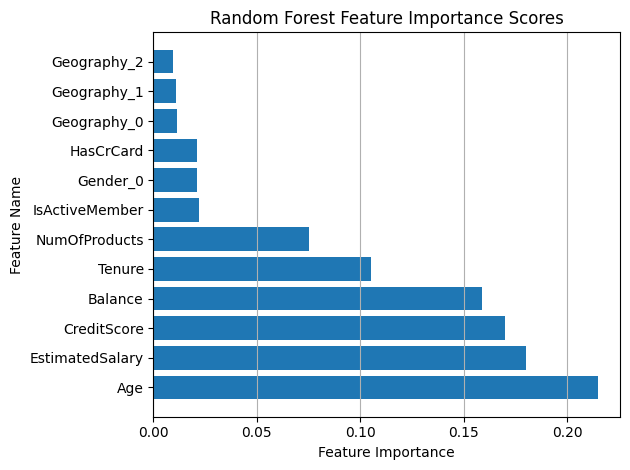

In [278]:
best_model = tuned_rf
feature_importances = []
for i in range(len(x.columns)):
    feature_name = x.columns[i]
    importance = best_model.feature_importances_[i]
    FeatureImportance(feature_name, importance)
    feature_importances.append(FeatureImportance(feature_name, importance))
    feature_importances.sort()
    
feature_names = [feature_importance.name for feature_importance in feature_importances]
feature_importances = [feature_importance.importance for feature_importance in feature_importances]

feature_importance_bar(feature_names, feature_importances)

## Model Voting

In [279]:
# Includes ALL examined classifiers.
voting_clf_1 = VotingClassifier(
    estimators = [
        ('tuned_dt', tuned_dt),
        ('tuned_lr', tuned_lr),
        ('tuned_mlp', tuned_mlp),
        ('tuned_nb', tuned_nb),
        ('tuned_svm', tuned_svm),
    ],
    voting='soft',
    n_jobs=-1
)

# Includes all examined classifiers EXCEPT decision tree (since RandomForest is an ensemble of DecisionTrees and less prone to overfitting).
voting_clf_2 = VotingClassifier(
    estimators = [
        ('tuned_lr', tuned_lr),
        ('tuned_mlp', tuned_mlp),
        ('tuned_nb', tuned_nb),
        ('tuned_svm', tuned_svm),
    ],
    voting='soft',
    n_jobs=-1
)

# Only accepts classifiers that are BETTER than random guessing (50%). Hence Logistic Regression and Naive Bayes are not included.
voting_clf_3 = VotingClassifier(
    estimators = [
        ('tuned_dt', tuned_dt),
        ('tuned_mlp', tuned_mlp),
        ('tuned_svm', tuned_svm),
    ],
    voting='soft',
    n_jobs=-1
)

voting_metrics_1, voting_auc_1 = test_model(voting_clf_1, x_std, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=True)
voting_metrics_2, voting_auc_2 = test_model(voting_clf_2, x_std, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=True)
voting_metrics_3, voting_auc_3 = test_model(voting_clf_3, x_std, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=True)

VotingClassifier(estimators=[('tuned_dt',
                              DecisionTreeClassifier(ccp_alpha=np.float64(0.0),
                                                     class_weight={0: 0.033,
                                                                   1: 0.967},
                                                     max_depth=48,
                                                     random_state=123)),
                             ('tuned_lr',
                              LogisticRegression(C=0.1,
                                                 class_weight={0: 0.409,
                                                               1: 0.591},
                                                 penalty='l1', random_state=123,
                                                 solver='liblinear')),
                             ('tuned_mlp',
                              MLPClassifier(hidden_layer_sizes=(50, 50),
                                            max_iter=1000, random_stat

## Model Stacking

In [280]:
# Stacking all examined classifiers
stack_1 = StackingClassifier(
    estimators = [
        ('tuned_dt', tuned_dt),
        ('tuned_lr', tuned_lr),
        ('tuned_mlp', tuned_mlp),
        ('tuned_nb', tuned_nb),
        ('tuned_svm', tuned_svm),
    ],
    final_estimator=tuned_rf,
    cv=5,
    n_jobs=-1
)

# Includes all examined classifiers minus decision tree (since RandomForest is an ensemble of DecisionTrees and less prone to overfitting)
stack_2 = StackingClassifier(
    estimators = [
        ('tuned_lr', tuned_lr),
        ('tuned_mlp', tuned_mlp),
        ('tuned_nb', tuned_nb),
        ('tuned_svm', tuned_svm),
    ],
    final_estimator=tuned_rf,
    cv=5,
    n_jobs=-1
)

# Only includes classifiers that are better than random guessing (50%). Hence Logistic Regression and Naive Bayes are not included
stack_3 = StackingClassifier(
    estimators = [
        ('tuned_dt', tuned_dt),
        ('tuned_mlp', tuned_mlp),
        ('tuned_svm', tuned_svm),
    ],
    final_estimator=tuned_rf,
    cv=5,
    n_jobs=-1
)

stack_metrics_1, stack_auc_1 = test_model(stack_1, x_std, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=True)
stack_metrics_2, stack_auc_2 = test_model(stack_2, x_std, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=True)
stack_metrics_3, stack_auc_3 = test_model(stack_3, x_std, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=True)

StackingClassifier(cv=5,
                   estimators=[('tuned_dt',
                                DecisionTreeClassifier(ccp_alpha=np.float64(0.0),
                                                       class_weight={0: 0.033,
                                                                     1: 0.967},
                                                       max_depth=48,
                                                       random_state=123)),
                               ('tuned_lr',
                                LogisticRegression(C=0.1,
                                                   class_weight={0: 0.409,
                                                                 1: 0.591},
                                                   penalty='l1',
                                                   random_state=123,
                                                   solver='liblinear')),
                               ('tuned_mlp',
                                MLPClassi

## Summary Table for Model Combinations

In [281]:
model_names = ['Stacked 1', 'Voting 1', 'Stacked 2', 'Voting 2', 'Stacked 3', 'Voting 3',]
model_metrics_list = [stack_metrics_1, voting_metrics_1, stack_metrics_2, voting_metrics_2, stack_metrics_3, voting_metrics_3]
display_and_store_metrics(model_names, model_metrics_list, 'model_combo_results')

,F1-Score,Recall,Precision,Accuracy
Stacked 1,0.936,0.941,0.932,0.974
Voting 1,0.797,0.983,0.670,0.898
Stacked 2,0.930,0.931,0.929,0.972
Voting 2,0.757,0.961,0.625,0.875
Stacked 3,0.933,0.934,0.931,0.973
Voting 3,0.853,0.973,0.759,0.931
Average,0.868,0.954,0.808,0.937


# Model Comparison and Interpretation

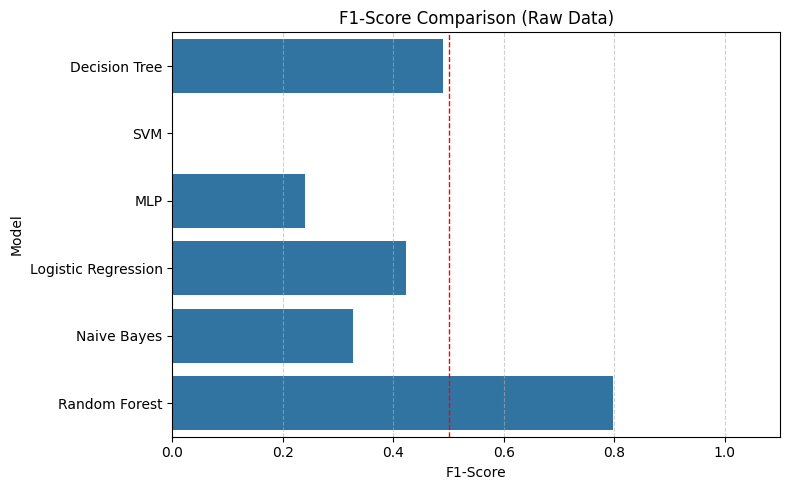

In [282]:
raw_model_metrics = {'Decision Tree': raw_dt_metrics,
                    'SVM': raw_svm_metrics,
                    'MLP': raw_mlp_metrics,
                    'Logistic Regression': raw_lr_metrics,
                    'Naive Bayes': raw_nb_metrics,
                    'Random Forest': raw_rf_metrics}

visualize_metrics(raw_model_metrics, 'Raw Data')

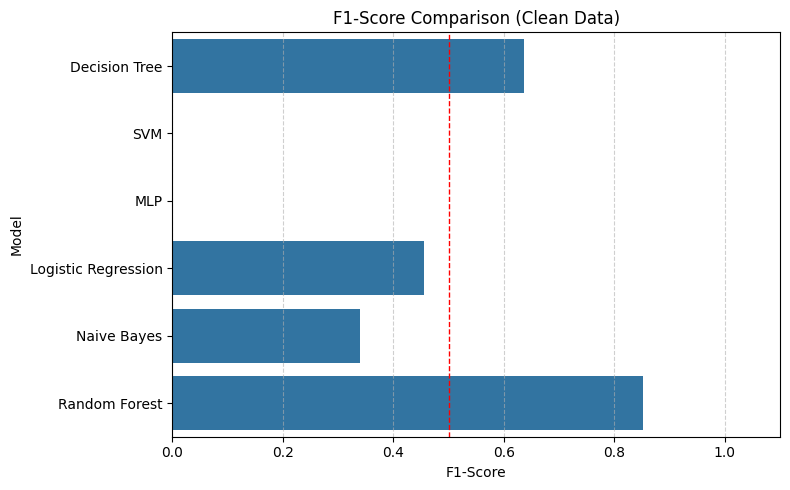

In [283]:
clean_model_metrics = {'Decision Tree': clean_dt_metrics,
                       'SVM': clean_svm_metrics,
                       'MLP': clean_mlp_metrics,
                       'Logistic Regression': clean_lr_metrics,
                       'Naive Bayes': clean_nb_metrics,
                       'Random Forest': clean_rf_metrics}

visualize_metrics(clean_model_metrics, 'Clean Data')

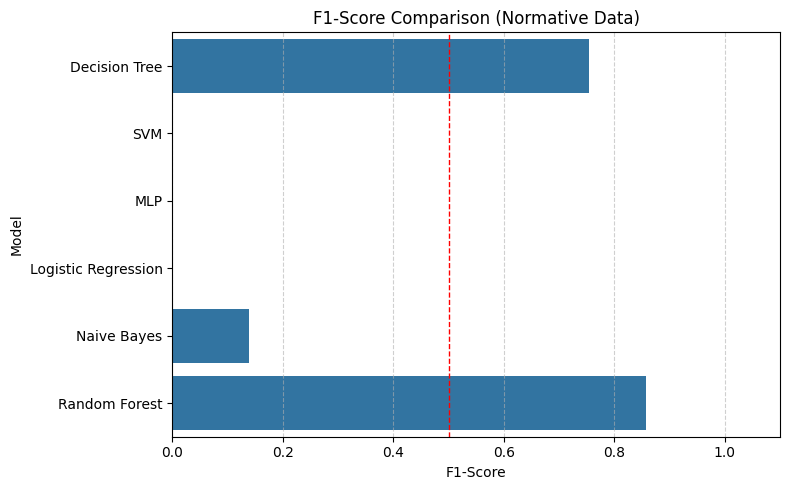

In [284]:
norm_model_metrics = {'Decision Tree': norm_dt_metrics,
                      'SVM': norm_svm_metrics,
                      'MLP': norm_mlp_metrics,
                      'Logistic Regression': norm_lr_metrics,
                      'Naive Bayes': norm_nb_metrics,
                      'Random Forest': norm_rf_metrics}

visualize_metrics(norm_model_metrics, 'Normative Data')

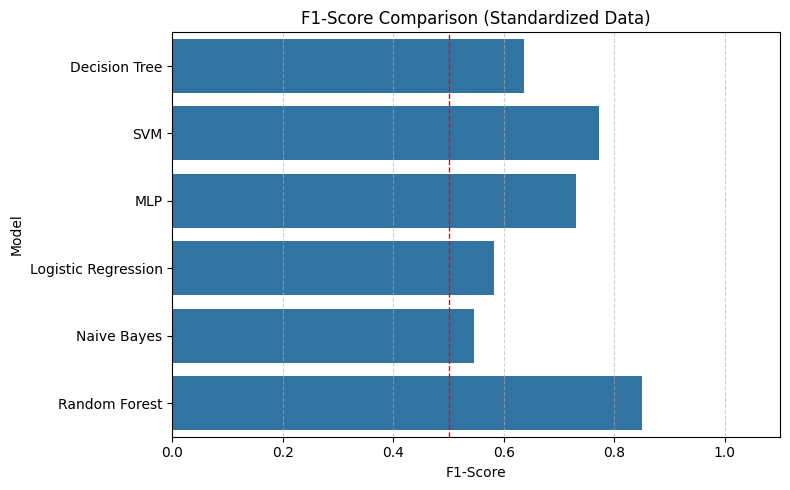

In [285]:
std_model_metrics = {'Decision Tree': std_dt_metrics,
                     'SVM': std_svm_metrics,
                     'MLP': std_mlp_metrics,
                     'Logistic Regression': std_lr_metrics,
                     'Naive Bayes': std_nb_metrics,
                     'Random Forest': std_rf_metrics}

visualize_metrics(std_model_metrics, 'Standardized Data')

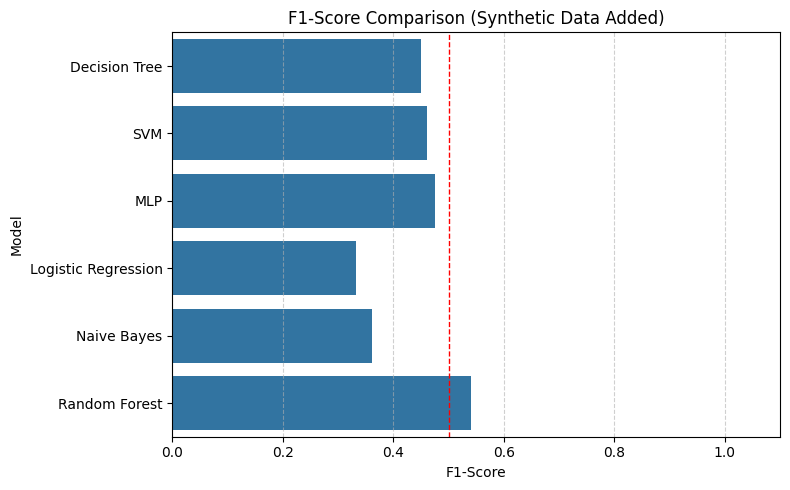

In [286]:
add_syn_model_metrics = {'Decision Tree': add_syn_dt_metrics,
                        'SVM': add_syn_svm_metrics,
                        'MLP': add_syn_mlp_metrics,
                        'Logistic Regression': add_syn_lr_metrics,
                        'Naive Bayes': add_syn_nb_metrics,
                        'Random Forest': add_syn_rf_metrics}

visualize_metrics(add_syn_model_metrics, 'Synthetic Data Added')

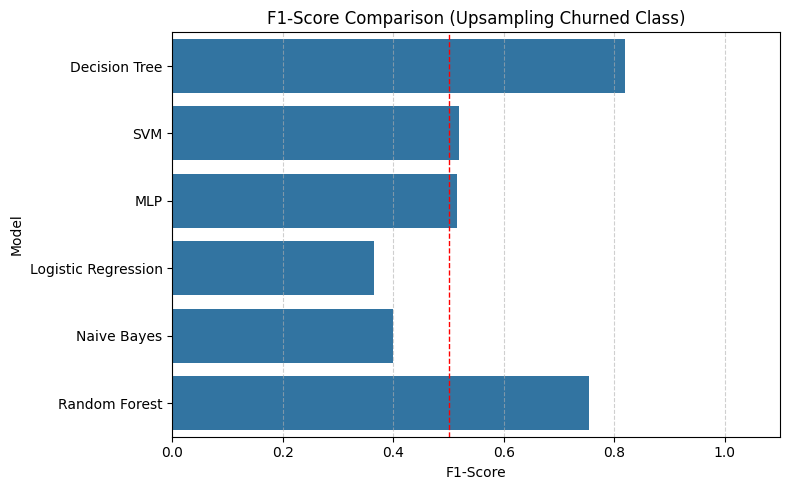

In [287]:
upsamp_model_metrics = {'Decision Tree': upsamp_dt_metrics,
                        'SVM': upsamp_svm_metrics,
                        'MLP': upsamp_mlp_metrics,
                        'Logistic Regression': upsamp_lr_metrics,
                        'Naive Bayes': upsamp_nb_metrics,
                        'Random Forest': upsamp_rf_metrics}

visualize_metrics(upsamp_model_metrics, 'Upsampling Churned Class')

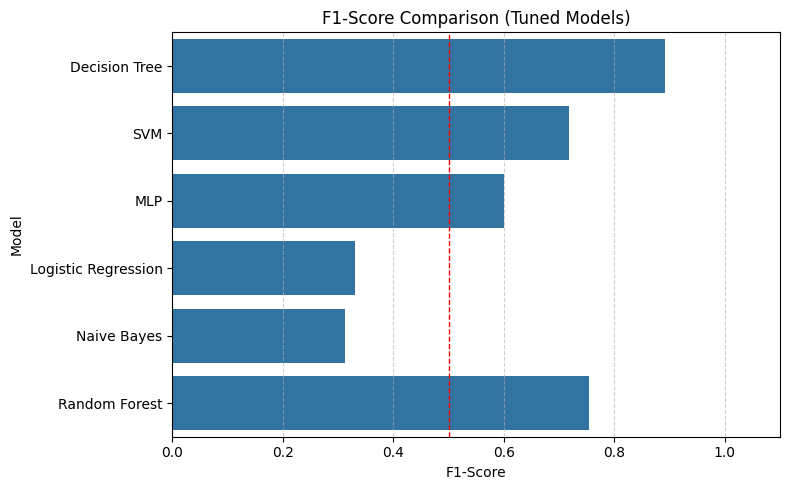

In [288]:
tuned_model_metrics = {'Decision Tree': tuned_dt_metrics,
                       'SVM': tuned_svm_metrics,
                       'MLP': tuned_mlp_metrics,
                       'Logistic Regression': tuned_lr_metrics,
                       'Naive Bayes': tuned_nb_metrics,
                       'Random Forest': tuned_rf_metrics}

visualize_metrics(tuned_model_metrics, 'Tuned Models')

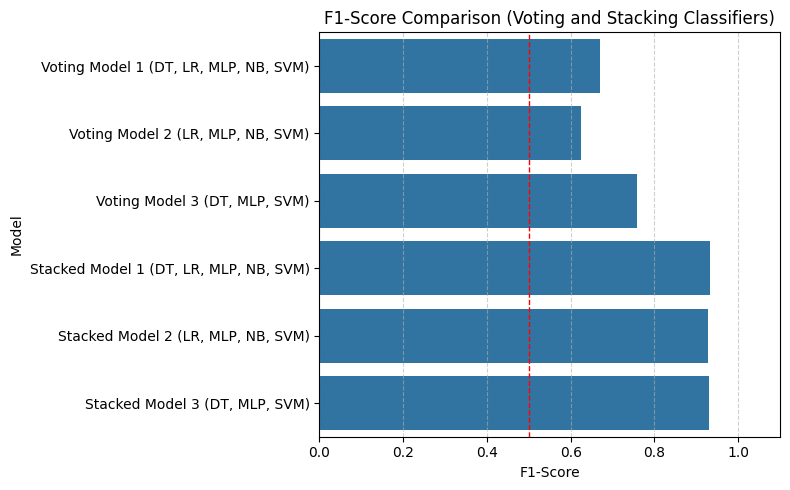

In [289]:
combo_model_metrics = {'Voting Model 1 (DT, LR, MLP, NB, SVM)': voting_metrics_1,
                        'Voting Model 2 (LR, MLP, NB, SVM)': voting_metrics_2,
                        'Voting Model 3 (DT, MLP, SVM)': voting_metrics_3,
                        'Stacked Model 1 (DT, LR, MLP, NB, SVM)': stack_metrics_1,
                        'Stacked Model 2 (LR, MLP, NB, SVM)': stack_metrics_2,
                        'Stacked Model 3 (DT, MLP, SVM)': stack_metrics_3}

visualize_metrics(combo_model_metrics, 'Voting and Stacking Classifiers')

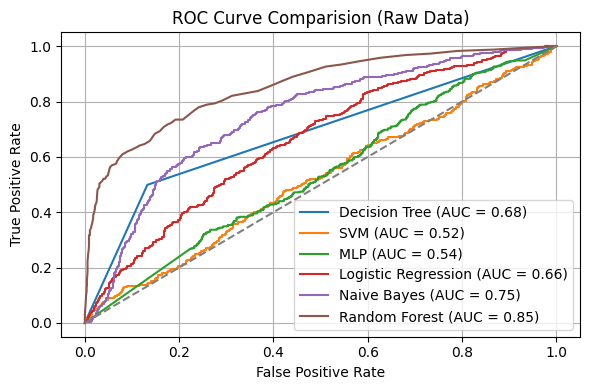

In [290]:
raw_model_aucs = {'Decision Tree': raw_dt_auc,
                  'SVM': raw_svm_auc,
                  'MLP': raw_mlp_auc,
                  'Logistic Regression': raw_lr_auc,
                  'Naive Bayes': raw_nb_auc,
                  'Random Forest': raw_rf_auc}

visualize_auc(raw_model_aucs, 'ROC Curve Comparision (Raw Data)')

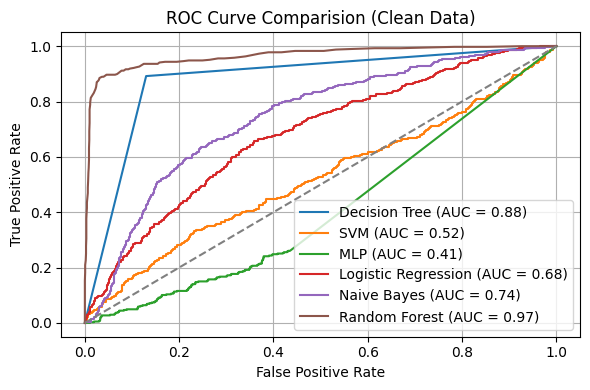

In [291]:
clean_model_aucs = {'Decision Tree': clean_dt_auc,
                    'SVM': clean_svm_auc,
                    'MLP': clean_mlp_auc,
                    'Logistic Regression': clean_lr_auc,
                    'Naive Bayes': clean_nb_auc,
                    'Random Forest': clean_rf_auc}

visualize_auc(clean_model_aucs, 'ROC Curve Comparision (Clean Data)')

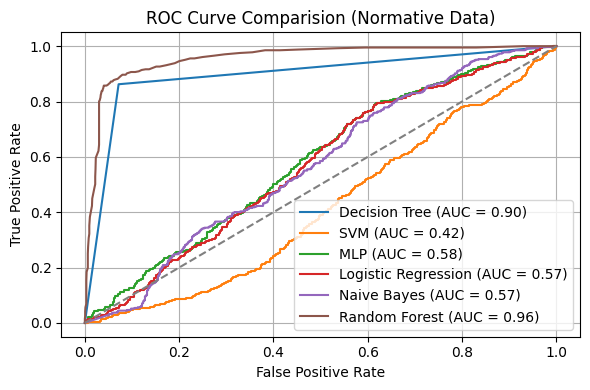

In [292]:
norm_model_aucs = {'Decision Tree': norm_dt_auc,
                   'SVM': norm_svm_auc,
                   'MLP': norm_mlp_auc,
                   'Logistic Regression': norm_lr_auc,
                   'Naive Bayes': norm_nb_auc,
                   'Random Forest': norm_rf_auc}

visualize_auc(norm_model_aucs, 'ROC Curve Comparision (Normative Data)')

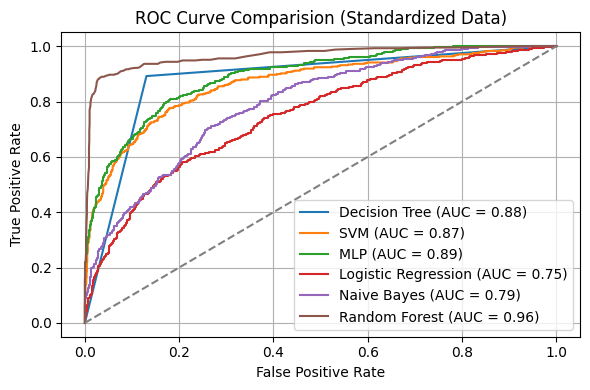

In [293]:
std_model_aucs = {'Decision Tree': std_dt_auc,
                    'SVM': std_svm_auc,
                    'MLP': std_mlp_auc,
                    'Logistic Regression': std_lr_auc,
                    'Naive Bayes': std_nb_auc,
                    'Random Forest': std_rf_auc}

visualize_auc(std_model_aucs, 'ROC Curve Comparision (Standardized Data)')

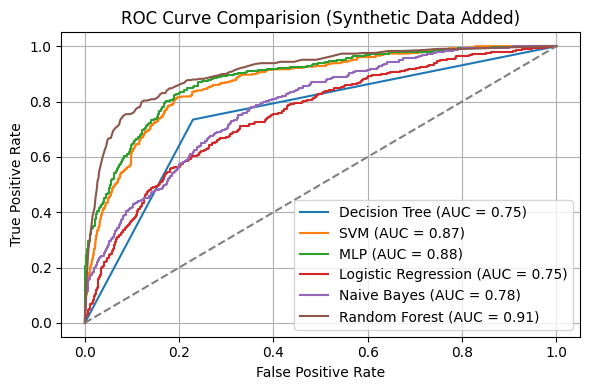

In [294]:
add_syn_model_aucs = {'Decision Tree': add_syn_dt_auc,
                      'SVM': add_syn_svm_auc,
                      'MLP': add_syn_mlp_auc,
                      'Logistic Regression': add_syn_lr_auc,
                      'Naive Bayes': add_syn_nb_auc,
                      'Random Forest': add_syn_rf_auc}

visualize_auc(add_syn_model_aucs, 'ROC Curve Comparision (Synthetic Data Added)')

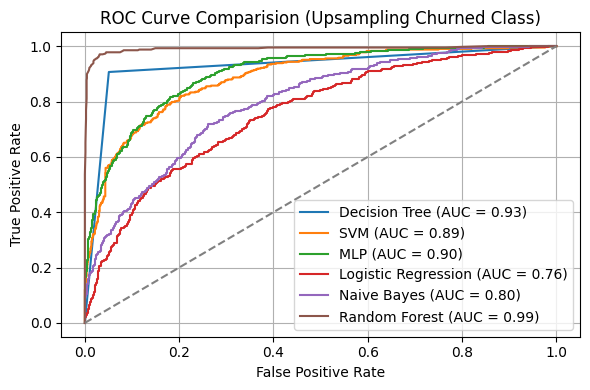

In [295]:
upsamp_model_aucs = {'Decision Tree': upsamp_dt_auc,
                     'SVM': upsamp_svm_auc,
                     'MLP': upsamp_mlp_auc,
                     'Logistic Regression': upsamp_lr_auc,
                     'Naive Bayes': upsamp_nb_auc,
                     'Random Forest': upsamp_rf_auc}

visualize_auc(upsamp_model_aucs, 'ROC Curve Comparision (Upsampling Churned Class)')

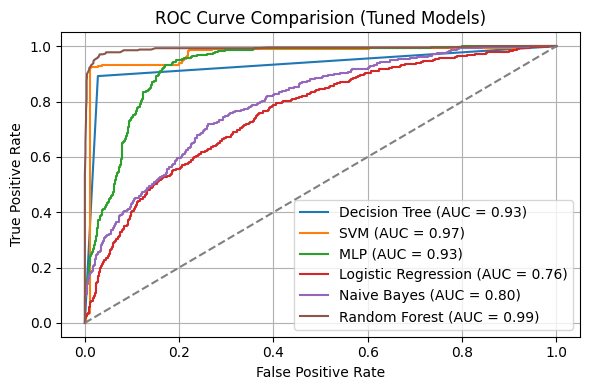

In [296]:
tuned_model_aucs = {'Decision Tree': tuned_dt_auc,
                    'SVM': tuned_svm_auc,
                    'MLP': tuned_mlp_auc,
                    'Logistic Regression': tuned_lr_auc,
                    'Naive Bayes': tuned_nb_auc,
                    'Random Forest': tuned_rf_auc}

visualize_auc(tuned_model_aucs, 'ROC Curve Comparision (Tuned Models)')

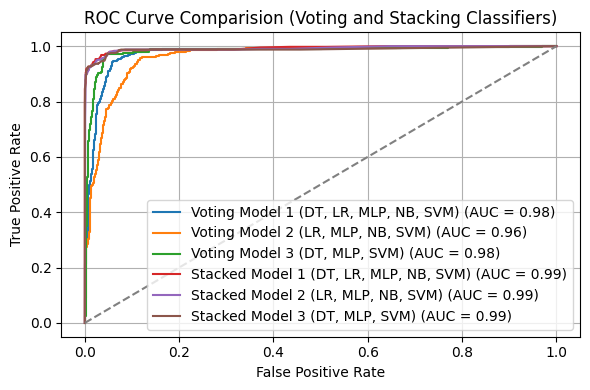

In [297]:
combo_model_aucs = {'Voting Model 1 (DT, LR, MLP, NB, SVM)': voting_auc_1,
                    'Voting Model 2 (LR, MLP, NB, SVM)': voting_auc_2,
                    'Voting Model 3 (DT, MLP, SVM)': voting_auc_3,
                    'Stacked Model 1 (DT, LR, MLP, NB, SVM)': stack_auc_1,
                    'Stacked Model 2 (LR, MLP, NB, SVM)': stack_auc_2,
                    'Stacked Model 3 (DT, MLP, SVM)': stack_auc_3}

visualize_auc(combo_model_aucs, 'ROC Curve Comparision (Voting and Stacking Classifiers)')